In [ ]:
!pip -q install transformers accelerate sentencepiece

Original Tensor Shape
torch.Size([3, 224, 224])
(Channels, Height, Width)


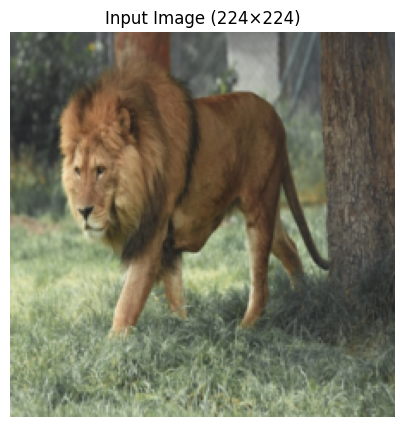


Patch Grid Shape: torch.Size([14, 14, 3, 16, 16])
Number of patches: 196
Final Patch Tensor Shape:
torch.Size([196, 3, 16, 16])


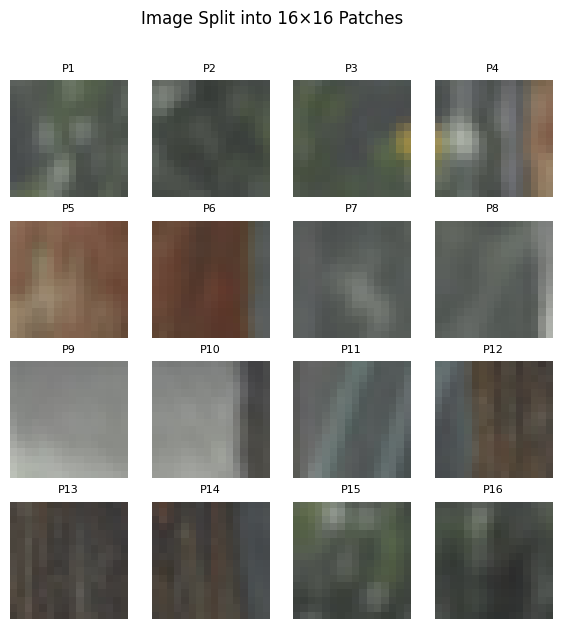

In [ ]:
# ===========================================
# Vision Transformer Step 1
# Image -> Patches
# ===========================================

import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import requests
from io import BytesIO

# Load image
url = "https://images.unsplash.com/photo-1546182990-dffeafbe841d?w=512"
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# Resize to ViT input size
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = transform(image)

print("="*60)
print("Original Tensor Shape")
print(img.shape)
print("(Channels, Height, Width)")
print("="*60)

plt.figure(figsize=(5,5))
plt.imshow(img.permute(1,2,0))
plt.title("Input Image (224×224)")
plt.axis("off")
plt.show()


# -------------------------------------------
# Split into 16x16 patches
# -------------------------------------------

patch_size = 16

patches = img.unfold(1, patch_size, patch_size)\
             .unfold(2, patch_size, patch_size)

patches = patches.permute(1,2,0,3,4)

num_patches = patches.shape[0]*patches.shape[1]

print("\nPatch Grid Shape:", patches.shape)
print("Number of patches:", num_patches)

patches = patches.reshape(num_patches,3,16,16)

print("Final Patch Tensor Shape:")
print(patches.shape)


# -------------------------------------------
# Display first 16 patches
# -------------------------------------------

fig,axs = plt.subplots(4,4,figsize=(7,7))

for i,ax in enumerate(axs.flat):
    ax.imshow(patches[i].permute(1,2,0))
    ax.axis("off")
    ax.set_title(f"P{i+1}",fontsize=8)

plt.suptitle("Image Split into 16×16 Patches")
plt.show()

In [ ]:
# ===========================================
# Pretrained Vision Transformer
# ===========================================

from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests
from io import BytesIO
import torch

# Load pretrained model
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

model = ViTModel.from_pretrained(
    "google/vit-base-patch16-224"
)

# Load image
url = "https://images.unsplash.com/photo-1546182990-dffeafbe841d?w=512"
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# Preprocess
inputs = processor(images=image, return_tensors="pt")

print("="*60)
print("Pixel Values Shape")
print(inputs["pixel_values"].shape)
print("="*60)

# Forward Pass
with torch.no_grad():
    outputs = model(**inputs)

print("\nLast Hidden State Shape")
print(outputs.last_hidden_state.shape)

print("\nPooler Output Shape")
print(outputs.pooler_output.shape)

print("\nCLS Token Embedding Shape")
print(outputs.last_hidden_state[:,0,:].shape)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pixel Values Shape
torch.Size([1, 3, 224, 224])

Last Hidden State Shape
torch.Size([1, 197, 768])

Pooler Output Shape
torch.Size([1, 768])

CLS Token Embedding Shape
torch.Size([1, 768])


# Depth Estimation

In [ ]:
# ============================================================
# Vision Transformer Application
# Real World Task : Monocular Depth Estimation
# Model : Intel DPT (Vision Transformer)
# ============================================================

!pip -q install transformers timm gradio accelerate pillow

import torch
import numpy as np
import gradio as gr
from PIL import Image
from transformers import DPTImageProcessor, DPTForDepthEstimation

print("Loading Vision Transformer model...")

processor = DPTImageProcessor.from_pretrained("Intel/dpt-large")
model = DPTForDepthEstimation.from_pretrained("Intel/dpt-large")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model Loaded Successfully!")
print("Running on:", device)


def estimate_depth(image):

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = outputs.predicted_depth

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=image.size[::-1],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

    depth = prediction.cpu().numpy()

    depth = (depth-depth.min())/(depth.max()-depth.min())
    depth = (depth*255).astype(np.uint8)

    return Image.fromarray(depth)


demo = gr.Interface(
    fn=estimate_depth,

    inputs=gr.Image(type="pil", label="Upload Any Image"),

    outputs=gr.Image(type="pil", label="Estimated Depth Map"),

    title="Vision Transformer Demo",
    description="""
Upload any image.

A pretrained Vision Transformer predicts the depth of every pixel.

Bright = Near Objects

Dark = Far Objects
    """,

    examples=[
        [
"https://images.unsplash.com/photo-1517841905240-472988babdf9?w=600"
        ]
    ]
)

demo.launch()

Loading Vision Transformer model...


preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.37GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

[transformers] DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully!
Running on: cpu
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e02c1dfb4e6def7c50.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Food Recognition

In [ ]:
# ==============================================================
# Food Recognition using Vision Transformer (ViT)
# Dataset : Food-101
# Model   : nateraw/food
# ==============================================================

!pip -q install transformers gradio pillow torch torchvision

import torch
import gradio as gr
from PIL import Image
from transformers import pipeline

print("Loading Food Recognition Model...")

device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    task="image-classification",
    model="nateraw/food",
    device=device
)

print("Model Loaded Successfully!")

# -------------------------------------------------

def predict_food(image):

    predictions = classifier(image)

    results = ""

    for pred in predictions[:5]:
        food = pred["label"].replace("_", " ").title()
        confidence = pred["score"] * 100

        results += f"{food} : {confidence:.2f}%\n"

    return results

# -------------------------------------------------

demo = gr.Interface(
    fn=predict_food,

    inputs=gr.Image(type="pil", label="Upload Food Image"),

    outputs=gr.Textbox(
        label="Top 5 Predictions",
        lines=6
    ),

    title="🍔 Food Recognition using Vision Transformer",

    description="""
Upload an image of food.

The pretrained Vision Transformer predicts the food category.
The model was trained on the Food-101 dataset.
""",

    examples=[
        ["https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=600"],  # Pizza
        ["https://images.unsplash.com/photo-1550547660-d9450f859349?w=600"],      # Burger
        ["https://images.unsplash.com/photo-1546069901-ba9599a7e63c?w=600"]       # Salad
    ]
)

demo.launch()

Loading Food Recognition Model...


config.json:   0%|          | 0.00/5.58k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  344MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  344MB            

model.safetensors: downloading bytes:           |  0.00B            

Model Loaded Successfully!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://11b865bfb30e81f25e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Flower Classification

In [ ]:
# ==========================================================
# Vision Transformer Flower Classification
# Model: vit-base-patch16-224 fine-tuned on Oxford Flowers-102
# ==========================================================

!pip -q install transformers gradio pillow torch torchvision

import torch
import gradio as gr
from transformers import pipeline

print("Loading Vision Transformer...")

device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    "image-classification",
    model="loretyan/vit-base-oxford-flowers-102",
    device=device
)

print("Model Loaded Successfully!")

# ----------------------------------------------------------

def classify_flower(image):

    predictions = classifier(image)

    output = "🌼 Top Predictions\n\n"

    for i, pred in enumerate(predictions[:5], 1):

        flower = pred["label"].replace("_", " ").title()
        confidence = pred["score"] * 100

        output += f"{i}. {flower}\n"
        output += f"   Confidence : {confidence:.2f}%\n\n"

    return output


# ----------------------------------------------------------

demo = gr.Interface(

    fn=classify_flower,

    inputs=gr.Image(type="pil", label="Upload a Flower Image"),

    outputs=gr.Textbox(
        label="Prediction",
        lines=12
    ),

    title="🌸 Vision Transformer Flower Recognition",

    description="""
Upload a flower image.

A pretrained Vision Transformer predicts the flower species
and returns the Top-5 predictions.
"""
)

demo.launch()

Loading Vision Transformer...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model Loaded Successfully!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eedcc7c89c0acd23ed.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# A Comparative Analysis
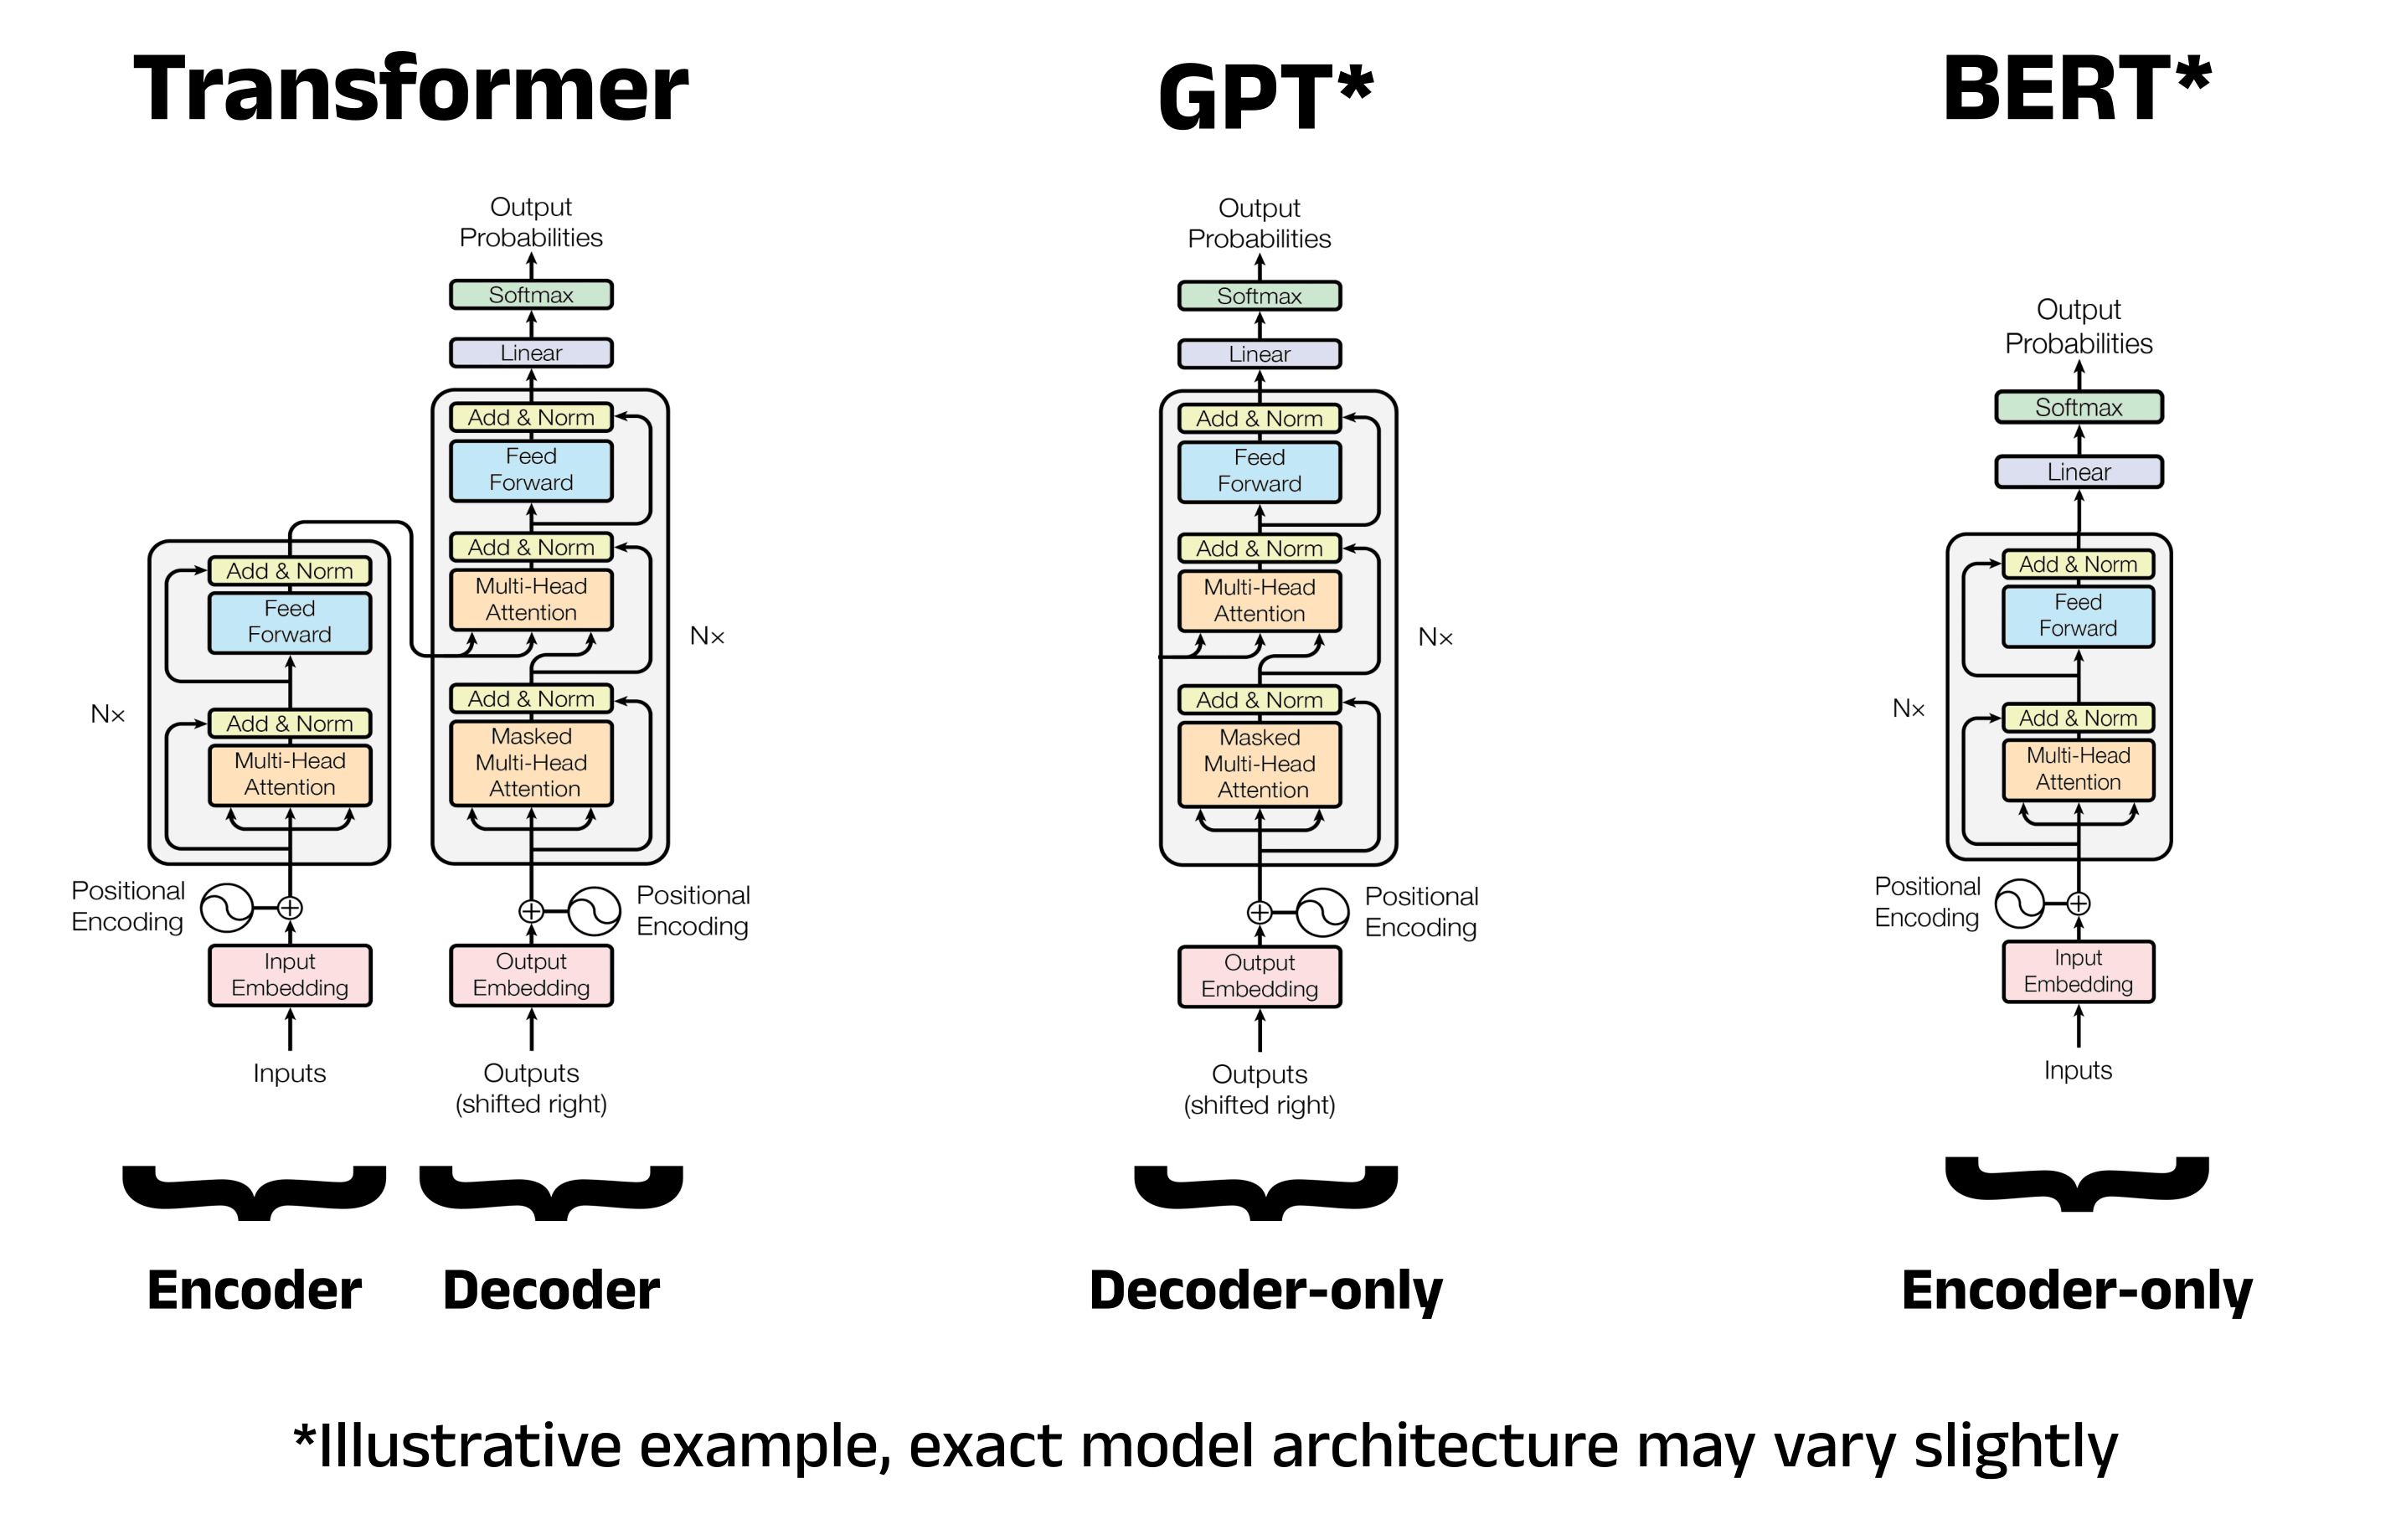

# Bidirectional Encoder Representations from Transformers - BERT

*   BERTBASE has 12 layers in the Encoder stack while BERTLARGE has 24 layers in the Encoder stack.
*   BERTBASE contains 110M parameters while BERTLARGE has 340M parameters


In [1]:
# Mini-BERT MLM demo that actually *learns* — no hard-coded targets.
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)
random.seed(42)



**Vocaublary and Helper**

In [2]:
# --------- 1) Vocabulary & helpers ----------
vocab = {"[PAD]":0, "[MASK]":1, "i":2, "love":3, "bert":4, "model":5, "is":6, "great":7, "you":8, "learn":9}
id2word = {i:w for w,i in vocab.items()}
vocab_size = len(vocab)

def encode(sent, max_len=6):
    ids = [vocab.get(t,0) for t in sent]
    # pad to max_len
    if len(ids) < max_len:
        ids = ids + [vocab["[PAD]"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return torch.tensor([ids], dtype=torch.long)  # shape (1, T)



**Dummy Dataset**

In [3]:
# --------- 2) Small dataset (complete sentences, no masks yet) ----------
# We'll create many maskings from these base sentences
base_sentences = [
    ["i", "love", "bert", "model"],        # typical
    ["bert", "is", "great"],               # short
    ["you", "learn", "bert"],              # another
    ["i", "love", "you", "bert"],          # variation
]

max_len = 6  # small fixed length

**Masking**

In [4]:
# --------- 3) Masking utility (creates input_ids and label tensor) ----------
def make_masked_example(full_sent, n_masks=1):
    # full_sent: list of tokens (no padding)
    # choose positions to mask (not padding)
    sent = full_sent.copy()
    L = len(sent)
    mask_positions = random.sample(range(L), k=min(n_masks, L))
    input_sent = sent.copy()
    for p in mask_positions:
        input_sent[p] = "[MASK]"
    inp = encode(input_sent, max_len=max_len)  # (1,T)
    labels = torch.full_like(inp, -100)        # ignore index default
    for p in mask_positions:
        labels[0, p] = vocab[sent[p]]           # place correct token id at mask pos
    return inp, labels, input_sent, mask_positions

# Create training examples (multiple masked versions)
train_examples = []
for s in base_sentences:
    # create several masked variants per sentence (so model sees patterns)
    for _ in range(6):  # 6 variants each (small dataset but varied masks)
        inp, labels, inp_sent, mpos = make_masked_example(s, n_masks=random.choice([1,1,2]))
        train_examples.append((inp, labels, inp_sent, mpos))

random.shuffle(train_examples)

# Keep one held-out sentence (unseen during training) to test generalization
held_out = ["you", "love", "bert"]



**Model Implementation**

In [5]:
# --------- 4) Model (very small) ----------
class MiniEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=32):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(max_len, d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads=2, batch_first=True)
        self.out = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, vocab_size))
    def forward(self, x):
        B,T = x.shape
        pos_ids = torch.arange(T).unsqueeze(0).expand(B,T)
        h = self.tok(x) + self.pos(pos_ids)
        h, _ = self.attn(h,h,h)
        logits = self.out(h)
        return logits  # (B,T,V)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MiniEncoder(vocab_size).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

# --------- 5) Helper: show predictions for any input ----------
def show_predictions(inp_tensor, topk=3):
    model.eval()
    with torch.no_grad():
        logits = model(inp_tensor.to(device))  # (1,T,V)
        probs = F.softmax(logits, dim=-1)
        topk_vals, topk_idx = probs.topk(topk, dim=-1)  # (1,T,topk)
    out = []
    for i in range(inp_tensor.shape[1]):
        token_id = inp_tensor[0,i].item()
        token = id2word.get(token_id, "[UNK]")
        top = [(id2word.get(int(topk_idx[0,i,j].item()),"[UNK]"), float(topk_vals[0,i,j].item())) for j in range(topk)]
        out.append((i, token, top))
    return out

**Initial Predictions and Final Predictions**

In [6]:
# --------- 6) Show initial predictions (before training) ----------
print("=== BEFORE TRAINING (initial predictions) ===")
example_inp, example_labels, example_sent, example_mpos = train_examples[0]
print("Input sentence (with [MASK]):", example_sent)
preds_before = show_predictions(example_inp)
for pos, tok, top in preds_before:
    if tok == "[MASK]":
        print(f" Mask pos {pos} top guesses:", top)

# Also show held-out before training
print("\nHeld-out input (before training):", held_out)
held_inp = encode([w if w!="#" else "#" for w in held_out], max_len=max_len)  # no masks here; we'll mask one token
# make a masked held-out version (mask one pos)
held_inp_masked, held_labels, _, mpos = make_masked_example(held_out, n_masks=1)
print(" Held-out masked:", [id2word[x.item()] for x in held_inp_masked[0]])
print(" Held-out predictions before:")
for pos,tok,top in show_predictions(held_inp_masked):
    if tok=="[MASK]":
        print(f"  pos {pos}:", top)

# --------- 7) Training loop ----------
print("\n=== TRAINING ===")
model.train()
epochs = 50
for ep in range(1, epochs+1):
    total_loss = 0.0
    for inp, labels, _, _ in train_examples:
        inp = inp.to(device)
        labels = labels.to(device)
        logits = model(inp)              # (1,T,V)
        loss = loss_fn(logits.view(-1, vocab_size), labels.view(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    if ep % 10 == 0 or ep==1:
        print(f" Epoch {ep:2d}  avg_loss={(total_loss/len(train_examples)):.4f}")

# --------- 8) AFTER TRAINING: show predictions ----------
print("\n=== AFTER TRAINING ===")
print("Same example input:", example_sent)
for pos,tok,top in show_predictions(example_inp):
    if tok=="[MASK]":
        print(f" Mask pos {pos} top guesses:", top)

# Held-out (unseen) test
held_inp_masked, held_labels, held_inp_sent, held_mpos = make_masked_example(held_out, n_masks=1)
print("\nHeld-out masked input (unseen during training):", held_inp_sent)
for pos,tok,top in show_predictions(held_inp_masked):
    if tok=="[MASK]":
        print(f" Held-out mask pos {pos} top guesses:", top)

=== BEFORE TRAINING (initial predictions) ===
Input sentence (with [MASK]): ['[MASK]', 'learn', 'bert']
 Mask pos 0 top guesses: [('love', 0.1286187320947647), ('you', 0.11986420303583145), ('[MASK]', 0.10654444992542267)]

Held-out input (before training): ['you', 'love', 'bert']
 Held-out masked: ['you', 'love', '[MASK]', '[PAD]', '[PAD]', '[PAD]']
 Held-out predictions before:
  pos 2: [('love', 0.12699280679225922), ('you', 0.11489228904247284), ('[MASK]', 0.1082569807767868)]

=== TRAINING ===
 Epoch  1  avg_loss=1.9930
 Epoch 10  avg_loss=0.8861
 Epoch 20  avg_loss=1.6795
 Epoch 30  avg_loss=1.6080
 Epoch 40  avg_loss=1.5885
 Epoch 50  avg_loss=1.5801

=== AFTER TRAINING ===
Same example input: ['[MASK]', 'learn', 'bert']
 Mask pos 0 top guesses: [('bert', 0.27793270349502563), ('you', 0.20155081152915955), ('is', 0.13977624475955963)]

Held-out masked input (unseen during training): ['you', 'love', '[MASK]']
 Held-out mask pos 2 top guesses: [('bert', 0.40617987513542175), ('you

# ** A Pretrained Model to Implement the Masked Langauge Model**

In [7]:
from transformers import pipeline
import gradio as gr

# Load pretrained BERT fill-mask pipeline
fill = pipeline("fill-mask", model="bert-base-uncased")

def predict_mask(sentence):
    try:
        preds = fill(sentence)
        results = []
        for p in preds:
            results.append(f"{p['sequence']} (score={p['score']:.3f})")
        return "\n".join(results)
    except Exception as e:
        return f"Error: {str(e)}"

# Gradio Interface
title = "BERT Masked Language Modeling Demo"
description = """
Enter a sentence containing the special token `[MASK]`.
BERT will predict the most likely words to fill the mask based on context.
Example: `I love [MASK] models.`
"""

iface = gr.Interface(
    fn=predict_mask,
    inputs=gr.Textbox(lines=2, placeholder="Type your sentence with [MASK]..."),
    outputs="text",
    title=title,
    description=description,
    examples=[
        ["I love [MASK] models."],
        ["The capital of France is [MASK]."],
        ["He plays [MASK] every weekend."]
    ]
)

iface.launch()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f4aa8bed6f8aed029.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **LETS PLAY  **

**Task 1 — Change the mask position**

**Task 2 — Create a custom challenge sentence**



# A Pretrained Model to Implement the Sentiment Analysis

In [8]:
import gradio as gr
from transformers import pipeline

# Load pre-trained sentiment analysis pipeline
# This model predicts sentiment scores: 1 to 5 stars
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Function to get prediction
def analyze_sentiment(text):
    results = sentiment_pipeline(text)
    label = results[0]['label']
    score = results[0]['score']
    return f"Prediction: {label} stars\nConfidence: {score:.2f}"

# Build Gradio Interface
app = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Type a review here..."),
    outputs="text",
    title="BERT Sentiment Analysis",
    description="Enter a sentence or review, and BERT will predict the sentiment (1 to 5 stars)."
)

app.launch()

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b5b2817a75e499d04.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Generative Pre-training Transformer - GPT**



*  GPT models from 1 to 5 have seen significant advancements in parameters and
capabilities.
*   GPT-1 had 117 million parameters
*  GPT-2 increased this to 1.5 billion.
*  GPT-3 boasted 175 billion parameters,
*  GPT-4, released in 2023, is estimated to have trillions.
*   GPT-5, released in August 2025

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ===== Vocabulary =====
vocab = ["the", "cat", "sat", "on", "mat",
         "dog", "barked", "at", "moon",
         "bird", "sang", "in", "tree",
         "sun", "shone", "bright",
         ".", "and", "then", "ran", "away"]

word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

vocab_size = len(vocab)
block_size = 8
embed_dim = 32
n_heads = 2
n_layers = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== Toy Story Dataset =====
stories = [
    "the cat sat on the mat",
    "the dog barked at the moon",
    "the bird sang in the tree",
    "the sun shone bright",
    "the cat and then ran away",
]
def encode(s):
    ids = [word_to_id[w] for w in s.split()]
    ids += [0] * (block_size - len(ids))
    return ids[:block_size]

data = torch.tensor([encode(s) for s in stories], dtype=torch.long, device=device)
targets = data.clone()




**GPT BLOCK**

In [2]:
# ===== GPT Block =====
class GPTBlock(nn.Module):
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.ReLU(),
            nn.Linear(embed_dim*4, embed_dim)
        )
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        T = x.size(1)
        attn_mask = torch.tril(torch.ones(T, T, device=x.device)) == 0
        attn_out, _ = self.attn(x, x, x, attn_mask=attn_mask)
        x = self.ln1(x + attn_out)
        ff_out = self.ff(x)
        x = self.ln2(x + ff_out)
        return x

# ===== Mini GPT =====
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(block_size, embed_dim)
        self.blocks = nn.Sequential(*[GPTBlock(embed_dim, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.token_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=device))
        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

    def generate(self, idx, max_new_tokens=5):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        return idx



**Train the model and Use User Promt**

In [3]:
# ===== Train =====
model = MiniGPT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for epoch in range(200):
    optimizer.zero_grad()
    logits = model(data)
    loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# ===== User Prompt =====
user_prompt = input("\nEnter a starting prompt (use words from vocab):\n")
try:
    prompt_ids = torch.tensor([[word_to_id[w] for w in user_prompt.split()]], device=device)
except KeyError as e:
    print(f"Error: Word '{e.args[0]}' not in vocabulary.")
    exit()

generated_ids = model.generate(prompt_ids, max_new_tokens=5)
generated_words = [id_to_word[i] for i in generated_ids[0].tolist()]

print("\nPrompt:", user_prompt)
print("Generated:", " ".join(generated_words))

Epoch 50 | Loss: 0.4715
Epoch 100 | Loss: 0.1329
Epoch 150 | Loss: 0.0650
Epoch 200 | Loss: 0.0392

Enter a starting prompt (use words from vocab):
the cat

Prompt: the cat
Generated: the cat cat cat on away barked


# A Predefined Model for the Text Generation using Hugging Face GPT

In [4]:
!pip install -q gradio transformers torch

import gradio as gr
from transformers import pipeline

# Load pre-trained GPT-2 text generation pipeline
generator = pipeline(
    "text-generation",
    model="gpt2",
    tokenizer="gpt2"
)

# Function for generating text
def generate_text(prompt, max_len=50, temperature=0.7):
    outputs = generator(
        prompt,
        max_length=max_len,
        temperature=temperature,
        num_return_sequences=1,
        do_sample=True
    )
    return outputs[0]['generated_text']

# Build Gradio interface
app = gr.Interface(
    fn=generate_text,
    inputs=[
        gr.Textbox(lines=2, placeholder="Enter a starting sentence..."),
        gr.Slider(20, 200, value=50, label="Max Length"),
        gr.Slider(0.1, 1.5, value=0.7, label="Creativity (Temperature)")
    ],
    outputs="text",
    title="GPT Text Generation",
    description="Type a prompt and let GPT continue writing your text."
)

app.launch()


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0adb65784c18092be6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Difference Between BERT and GPT

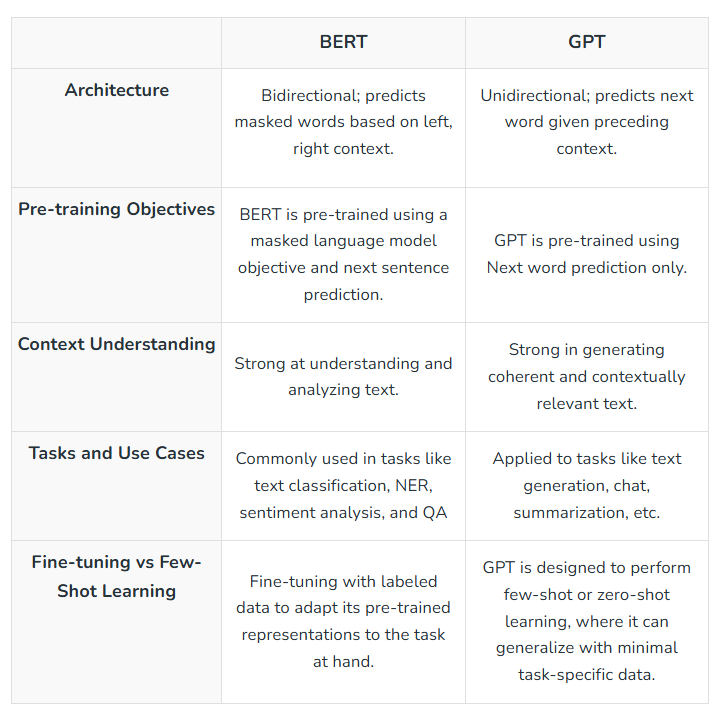

## T5 Text to Text Transformer

In [ ]:
# ============================================================
# T5 Text-to-Text Transformer
# Task: Text Summarization
# Model: google/flan-t5-base
# ============================================================

!pip -q install transformers gradio sentencepiece accelerate

import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Loading T5 Model...")

MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model Loaded Successfully!")
print("Running on:", device)

# ---------------------------------------------------------

def summarize(text):

    if len(text.strip()) == 0:
        return "Please enter some text."

    prompt = "Summarize the following text:\n\n" + text

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=4,
        early_stopping=True
    )

    summary = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return summary

# ---------------------------------------------------------

demo = gr.Interface(
    fn=summarize,

    inputs=gr.Textbox(
        lines=12,
        placeholder="Paste a long paragraph here..."
    ),

    outputs=gr.Textbox(
        lines=6,
        label="Summary"
    ),

    title="📝 T5 Text-to-Text Transformer",

    description="""
Task: Text Summarization

Input → Text

Output → Text

Model: Google FLAN-T5 Base
"""
)

demo.launch()

Loading T5 Model...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model Loaded Successfully!
Running on: cpu
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://37655055e2780bc37d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
